In [ ]:
### THIS CELL SETS UP THE GOOGLE COLAB ENVIRONMENT.
### IF RUNNING THIS NOTEBOOK LOCALLY, IT MAY BE SAFELY DELETED.

try:
    import google.colab
    RUNNING_IN_COLAB = True
except ImportError:
    RUNNING_IN_COLAB = False
except Exception as e:
    raise Exception("Could not figure out if running in a colab notebook\n") from e

if RUNNING_IN_COLAB:
    !pip install dataprob

## Bootstrap resampling

This notebook demonstrates the `bootstrap` fitter, which estimates parameter uncertainty
by running maximum likelihood fits on many pseudo-replicate datasets. Each pseudo-replicate
is generated by sampling new observations from $\mathcal{N}(y_{obs,i},\, y_{std,i})$.
The resulting distribution of parameter estimates makes no assumption about the shape of
the posterior — the 95% intervals are determined numerically from the sample distribution.

**When to use:** You suspect non-Gaussian parameter posteriors (asymmetric or multi-modal),
or you want uncertainty estimates without assuming a normal likelihood surface.

### Define model

We use a linear model $y = mx + b$. The same model and data are used across all fitter
notebooks so the outputs can be directly compared.

In [1]:
%matplotlib inline
import dataprob
import numpy as np

def linear_model(m=1, b=1, x=None):
    return m*x + b

### Generate noisy data

30 observations with m = 3, b = 1, and Gaussian noise (σ = 0.5).

In [2]:
true_params = {"m": 3.0, "b": 1.0}

x = np.linspace(0, 10, 30)
y_std = 0.5
y_obs = linear_model(x=x, **true_params) + np.random.normal(0, y_std, size=x.shape)

### Set up and run the fit

`num_bootstrap` controls how many pseudo-replicate datasets are generated and fit.
More replicates give smoother distributions but take proportionally longer. All remaining
keyword arguments are forwarded to `scipy.optimize.least_squares`.

In [6]:
f = dataprob.setup(linear_model,
                   method="bootstrap",
                   non_fit_kwargs={"x": x})

f.fit(y_obs=y_obs,
      y_std=y_std,
      num_bootstrap=5000,
      output_dir=None,
      method="trf",
      ftol=1e-8,
      xtol=1e-8,
      gtol=1e-8,
      x_scale=1.0,
      max_nfev=None,
      loss="linear",
      verbose=0)

  0%|          | 0/5000 [00:00<?, ?it/s]

### Examine fit results

`f.fit_df["estimate"]` is the mode of the bootstrap distribution (KDE maximum).
`f.fit_df["low_95"]` and `f.fit_df["high_95"]` are determined numerically — no normality
assumption. `f.samples` contains all 500 pseudo-replicate parameter vectors.

The corner plot shows the empirical joint distribution of parameters across pseudo-replicates:
any correlation or asymmetry in the posteriors is directly visible.

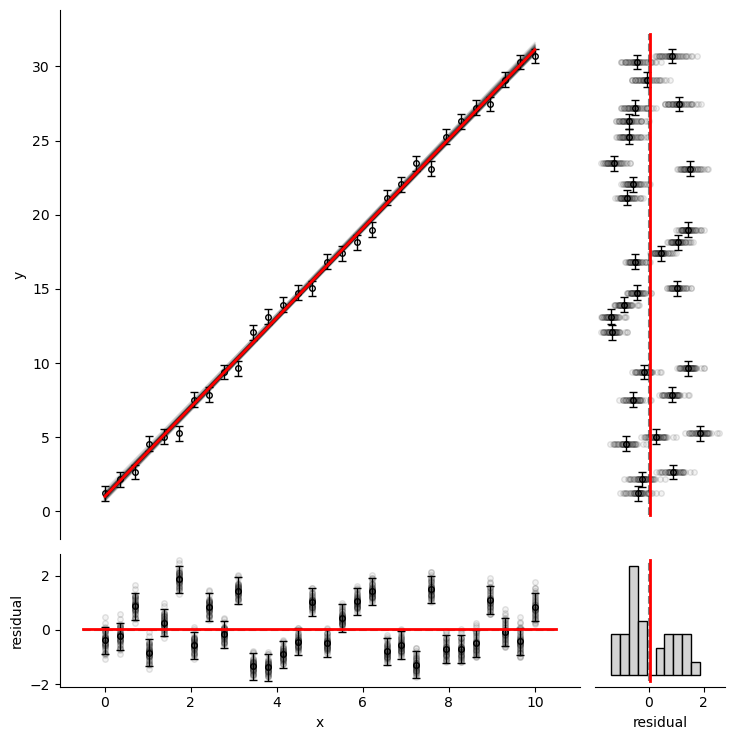

In [7]:
fig = dataprob.plot_summary(f, x_axis=x, x_label="x", y_label="y")

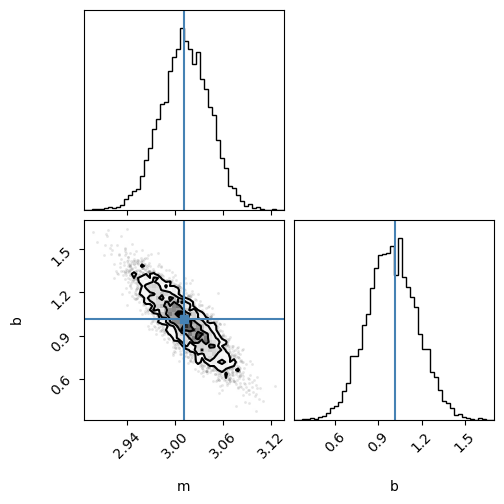

In [8]:
fig = dataprob.plot_corner(f)

In [9]:
f.fit_df

,name,estimate,std,low_95,high_95,guess,fixed,lower_bound,upper_bound,prior_mean,prior_std
name,,,,,,,,,,,
m,m,3.010619,0.030286,2.952028,3.070602,1.0,False,-inf,inf,NaN,NaN
b,b,1.015746,0.177470,0.652855,1.343016,1.0,False,-inf,inf,NaN,NaN


### Assess fit quality

`f.fit_quality` reports statistics on the fit using the ML estimate parameters.
It also shows the number of successful vs. failed pseudo-replicate fits — any failures
are stored as `np.nan` rows in `f.samples` and excluded from statistics.

In [10]:
f.fit_quality

,description,is_good,value,message
name,,,,
success,fit success status,True,True,
num_obs,number of observations,True,30,
num_param,number of fit parameters,True,2,There are 28 more observations than fit parame...
lnL,log likelihood,True,-19.696965,
chi2,chi^2 goodness-of-fit,True,0.527135,A p-value of 5.271e-01 for the a goodness-of-f...
reduced_chi2,reduced chi^2,True,0.957276,A reduced chi^2 value of 0.957 is consistent w...
mean0_resid,t-test for residual mean != 0,True,0.871263,A p-value of 8.713e-01 for the one-sample t-te...
durbin-watson,Durbin-Watson test for correlated residuals,True,2.212472,A Durbin-Watson test-statistic of 2.212 is con...
ljung-box,Ljung-Box test for correlated residuals,True,0.48757,A p-value of 4.876e-01 for the Ljung-Box test ...
